# 🚦 Traffic Object Detection — YOLOv8
### End-to-end pipeline: data prep → training → inference & counting

| Step | Description |
|------|-------------|
| 1 | Install dependencies |
| 2 | Organize raw data from zip |
| 3 | Convert VOC XML → YOLO labels |
| 4 | Verify dataset |
| 5 | Train YOLOv8 |
| 6 | Evaluate & visualize results |
| 7 | Inference + object counting |


## 📦 Step 1 — Install Dependencies

In [1]:
!pip install ultralytics opencv-python-headless matplotlib PyYAML --quiet
import ultralytics
ultralytics.checks()


Ultralytics 8.4.34 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 11901MiB)
Setup complete ✅ (12 CPUs, 62.6 GB RAM, 300.4/319.3 GB disk)


## 🔧 Step 2 — Imports & Config

In [10]:
import os, shutil, zipfile, random, yaml
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO

# ── Global config ─────────────────────────────────────────────────────────────
CLASSES      = ["Bike", "Bus", "Car", "Cng", "People", "Rickshaw","Truck","Mini-Truck","Cycle"]
DATASET_ROOT = Path("dataset")
RAW_IMAGES   = Path("raw/images")
RAW_ANNOTS   = Path("raw/annotations")
MODELS_DIR   = Path("models")
VAL_SPLIT    = 0.2
RANDOM_SEED  = 42
IMG_SIZE     = 640
EPOCHS       = 100
BATCH        = 32

print("Config loaded ✓")
print(f"Classes ({len(CLASSES)}): {CLASSES}")


Config loaded ✓
Classes (9): ['Bike', 'Bus', 'Car', 'Cng', 'People', 'Rickshaw', 'Truck', 'Mini-Truck', 'Cycle']


## 📂 Step 3 — Organize Raw Data from Zip

Place your `.zip` file in the working directory and set `ZIP_PATH` below.  
The function splits files by extension into `raw/images/` and `raw/annotations/`.


In [3]:
def organize_from_zip(zip_path, output_dir="."):
    """
    Extract zip and sort files:
        *.jpg / *.png  →  raw/images/
        *.xml          →  raw/annotations/
    Files are matched by stem name (same base name).
    Handles nested zips inside 'Annotated Images' folder.
    """
    IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    LABEL_EXTS = {".xml"}

    zip_path   = Path(zip_path)
    output_dir = Path(output_dir)
    tmp_dir    = output_dir / "_tmp_extract"

    img_out = output_dir / "raw" / "images"
    ann_out = output_dir / "raw" / "annotations"
    for d in [img_out, ann_out, tmp_dir]:
        d.mkdir(parents=True, exist_ok=True)

    print(f"Extracting main zip {zip_path.name} …")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(tmp_dir)

    # Extract nested zips inside 'Annotated Images'
    annotated_dir = tmp_dir / "Bangladeshi Traffic Flow Dataset" / "Annotated Images"
    if annotated_dir.exists():
        for nested_zip in annotated_dir.rglob("*.zip"):
            print(f"Extracting nested {nested_zip.name} …")
            with zipfile.ZipFile(nested_zip, "r") as zf:
                zf.extractall(tmp_dir)
            nested_zip.unlink()  # remove the zip after extraction
    else:
        print("Warning: 'Annotated Images' folder not found in the zip.")

    imgs_moved = anns_moved = skipped = 0

    for f in tmp_dir.rglob("*"):
        if not f.is_file():
            continue
        ext = f.suffix.lower()

        if ext in IMAGE_EXTS:
            dest = img_out / f.name
            if dest.exists():
                skipped += 1
            else:
                shutil.copy2(f, dest)
                imgs_moved += 1

        elif ext in LABEL_EXTS:
            dest = ann_out / f.name
            if dest.exists():
                skipped += 1
            else:
                shutil.copy2(f, dest)
                anns_moved += 1
        else:
            skipped += 1

    shutil.rmtree(tmp_dir)

    # Pairing check
    img_stems = {p.stem for p in img_out.iterdir() if p.suffix.lower() in IMAGE_EXTS}
    ann_stems = {p.stem for p in ann_out.iterdir() if p.suffix.lower() in LABEL_EXTS}
    only_img  = img_stems - ann_stems
    only_ann  = ann_stems - img_stems

    print(f"\n✅ Images moved      : {imgs_moved}  →  {img_out}")
    print(f"✅ Annotations moved : {anns_moved}  →  {ann_out}")
    print(f"⚠️  Skipped           : {skipped}")
    if only_img:
        print(f"⚠️  Images without XML : {sorted(only_img)[:5]}")
    if only_ann:
        print(f"⚠️  XMLs without image : {sorted(only_ann)[:5]}")


# ── Run ───────────────────────────────────────────────────────────────────────
ZIP_PATH = "Bangladeshi Traffic Flow Dataset.zip"   # ← change this

if Path(ZIP_PATH).exists():
    organize_from_zip(ZIP_PATH)
else:
    print(f"⚠️  '{ZIP_PATH}' not found — skipping. Place your zip and re-run.")

Extracting main zip Bangladeshi Traffic Flow Dataset.zip …
Extracting nested 4-LOC2-1830-1930-DL.v1i.voc.zip …
Extracting nested 5-LOC2-2000-2100-DL.v1i.voc.zip …
Extracting nested 2-LOC2-0830-0930-DL.v1i.voc.zip …
Extracting nested 1-LOC2-0700-0800-DL.v1i.voc.zip …
Extracting nested 3-LOC2-1200-1300-DL.v1i.voc.zip …
Extracting nested 1-LOC2-0700-0800-SL.v1i.voc.zip …
Extracting nested 5-LOC2-2000-2100-SL.v1i.voc.zip …
Extracting nested 3-LOC2-1200-1300-SL.v1i.voc.zip …
Extracting nested 4-LOC2-1830-1930-SL.v1i.voc.zip …
Extracting nested 2-LOC2-0830-0930-SL.v1i.voc.zip …
Extracting nested 1-LOC3-0700-0800-DL.v1i.voc.zip …
Extracting nested 5-LOC3-2000-2100-DL.v1i.voc.zip …
Extracting nested 2-LOC3-0830-0930-DL.v1i.voc.zip …
Extracting nested 3-LOC3-1200-1300-DL.v1i.voc.zip …
Extracting nested 4-LOC3-1830-1930-DL.v1i.voc.zip …
Extracting nested 4-LOC3-1830-1930-SL.v1i.voc.zip …
Extracting nested 5-LOC3-2000-2100-SL.v1i.voc.zip …
Extracting nested 1-LOC3-0700-0800-SL.v1i.voc.zip …
Extra

## 🔍 Step 4 — Preview Raw Data

Images found      : 23678
Annotations found : 23678


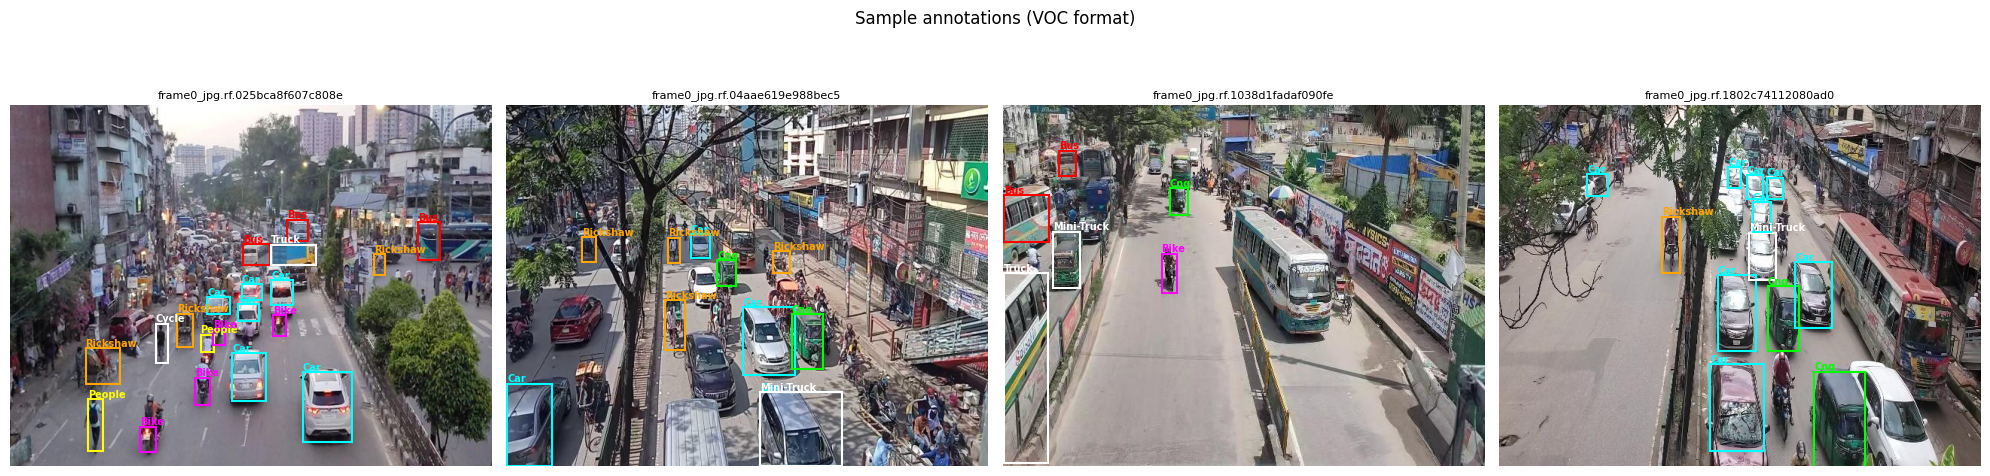

In [4]:
imgs  = sorted(RAW_IMAGES.glob("*.jpg")) + sorted(RAW_IMAGES.glob("*.png"))
xmls  = sorted(RAW_ANNOTS.glob("*.xml"))

print(f"Images found      : {len(imgs)}")
print(f"Annotations found : {len(xmls)}")

# Show up to 4 sample images with their bounding boxes
def show_voc_sample(img_path, xml_path, ax, classes):
    img = plt.imread(str(img_path))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(Path(img_path).stem[:30], fontsize=8)

    tree = ET.parse(xml_path)
    root = tree.getroot()
    COLOR = {"Cng":"lime","Rickshaw":"orange","Car":"cyan",
             "Bus":"red","Bike":"magenta","People":"yellow"}

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        bb   = obj.find("bndbox")
        xmin = float(bb.find("xmin").text)
        xmax = float(bb.find("xmax").text)
        ymin = float(bb.find("ymin").text)
        ymax = float(bb.find("ymax").text)
        rect = patches.Rectangle(
            (xmin, ymin), xmax-xmin, ymax-ymin,
            linewidth=1.5, edgecolor=COLOR.get(name,"white"), facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(xmin, ymin-3, name, color=COLOR.get(name,"white"),
                fontsize=7, fontweight="bold")

paired = [(i, RAW_ANNOTS / (i.stem + ".xml")) for i in imgs
          if (RAW_ANNOTS / (i.stem + ".xml")).exists()]

n_show = min(4, len(paired))
if n_show:
    fig, axes = plt.subplots(1, n_show, figsize=(5*n_show, 5))
    if n_show == 1:
        axes = [axes]
    for ax, (img_p, xml_p) in zip(axes, paired[:n_show]):
        show_voc_sample(img_p, xml_p, ax, CLASSES)
    plt.suptitle("Sample annotations (VOC format)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No paired image+XML found — add data and re-run.")


## 🔄 Step 5 — Convert VOC XML → YOLO Format & Split

In [5]:
def voc_to_yolo(xmin, xmax, ymin, ymax, W, H):
    cx = (xmin + xmax) / 2.0 / W
    cy = (ymin + ymax) / 2.0 / H
    w  = (xmax - xmin) / W
    h  = (ymax - ymin) / H
    return cx, cy, w, h


def convert_xml(xml_path, label_out_path, classes):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find("size")
    W, H = int(size.find("width").text), int(size.find("height").text)

    lines = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        if name not in classes:
            print(f"  [skip] unknown class '{name}' in {xml_path.name}")
            continue
        cls_id = classes.index(name)
        bb   = obj.find("bndbox")
        xmin = float(bb.find("xmin").text)
        xmax = float(bb.find("xmax").text)
        ymin = float(bb.find("ymin").text)
        ymax = float(bb.find("ymax").text)
        cx, cy, w, h = voc_to_yolo(xmin, xmax, ymin, ymax, W, H)
        lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

    label_out_path.write_text("\n".join(lines))


def prepare_dataset(raw_img_dir, raw_ann_dir, out_dir,
                    classes, val_split=0.2, seed=42):
    random.seed(seed)
    raw_img_dir = Path(raw_img_dir)
    raw_ann_dir = Path(raw_ann_dir)
    out_dir     = Path(out_dir)

    imgs = sorted(raw_img_dir.glob("*.jpg")) + sorted(raw_img_dir.glob("*.png"))
    paired = [p for p in imgs if (raw_ann_dir / (p.stem + ".xml")).exists()]
    random.shuffle(paired)

    split      = int(len(paired) * (1 - val_split))
    splits     = {"train": paired[:split], "val": paired[split:]}
    stats      = {}

    for split_name, files in splits.items():
        img_out = out_dir / "images" / split_name
        lbl_out = out_dir / "labels" / split_name
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

        for img_path in files:
            shutil.copy2(img_path, img_out / img_path.name)
            xml_path = raw_ann_dir / (img_path.stem + ".xml")
            convert_xml(xml_path, lbl_out / (img_path.stem + ".txt"), classes)

        stats[split_name] = len(files)

    # Write dataset.yaml
    yaml_content = {
        "path" : str(out_dir.resolve()),
        "train": "images/train",
        "val"  : "images/val",
        "nc"   : len(classes),
        "names": classes,
    }
    with open("dataset.yaml", "w") as f:
        yaml.dump(yaml_content, f, default_flow_style=False)

    print(f"\n✅ Dataset prepared")
    print(f"   Train : {stats['train']} images")
    print(f"   Val   : {stats['val']}   images")
    print(f"   YAML  : dataset.yaml")
    return stats


stats = prepare_dataset(RAW_IMAGES, RAW_ANNOTS, DATASET_ROOT,
                        CLASSES, val_split=VAL_SPLIT, seed=RANDOM_SEED)



✅ Dataset prepared
   Train : 18942 images
   Val   : 4736   images
   YAML  : dataset.yaml


## ✅ Step 6 — Verify YOLO Labels

Class distribution across full dataset:
  Class         Count
  --------------------
  Bike          15894
  Bus           51996
  Car           63107
  Cng           27823
  People        38779
  Rickshaw      60241
  Truck          1310
  Mini-Truck     5834
  Cycle           714
  TOTAL        265698


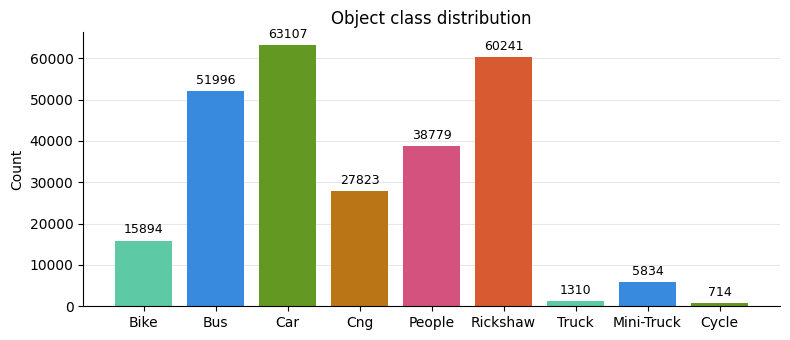

In [6]:
def check_labels(dataset_root, classes):
    root  = Path(dataset_root)
    total = Counter()

    for split in ["train", "val"]:
        lbl_dir = root / "labels" / split
        if not lbl_dir.exists():
            continue
        for lbl in lbl_dir.glob("*.txt"):
            for line in lbl.read_text().strip().splitlines():
                if line:
                    cls_id = int(line.split()[0])
                    total[classes[cls_id]] += 1

    print("Class distribution across full dataset:")
    print(f"  {'Class':<12} {'Count':>6}")
    print("  " + "-"*20)
    for cls in classes:
        print(f"  {cls:<12} {total.get(cls, 0):>6}")
    print(f"  {'TOTAL':<12} {sum(total.values()):>6}")

    # Bar chart
    counts = [total.get(c, 0) for c in classes]
    colors = ["#5DCAA5","#378ADD","#639922","#BA7517","#D4537E","#D85A30"]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    bars = ax.bar(classes, counts, color=colors, edgecolor="none", zorder=2)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title("Object class distribution", fontsize=12)
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3, zorder=1)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

check_labels(DATASET_ROOT, CLASSES)


## ⬇️ Step 7 — Download Pretrained Weights

In [7]:
MODELS_DIR.mkdir(exist_ok=True)
weights_path = MODELS_DIR / "yolov8n.pt"

if not weights_path.exists():
    print("Downloading yolov8n.pt …")
    !wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/yolov8n.pt -O {weights_path}
    print("Downloaded ✓")
else:
    print(f"Weights already present: {weights_path}")


Weights already present: models/yolov8n.pt


## 🏋️ Step 8 — Train YOLOv8

> **Tip:** Change `device=0` to `device='cpu'` if no GPU is available.  
> Reduce `epochs` or `batch` if you hit memory errors.


In [11]:
model = YOLO(str(weights_path))

results = model.train(
    data    = "dataset.yaml",
    epochs  = EPOCHS,
    imgsz   = IMG_SIZE,
    batch   = BATCH,
    patience= 20,          # early stop
    lr0     = 0.01,
    augment = True,
    project = "runs",
    name    = "traffic_detect",
    save    = True,
    val     = True,
    plots   = True,
    device  = 0,           # change to 'cpu' if needed
)

BEST_WEIGHTS = Path(results.save_dir) / "weights" / "best.pt"
print(f"\n✅ Training complete")
print(f"   Best weights : {BEST_WEIGHTS}")
print(f"   Results dir  : {results.save_dir}")


Ultralytics 8.4.34 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060, 11901MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=models/yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=traffic_detect3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, p

## 📈 Step 9 — Training Curves

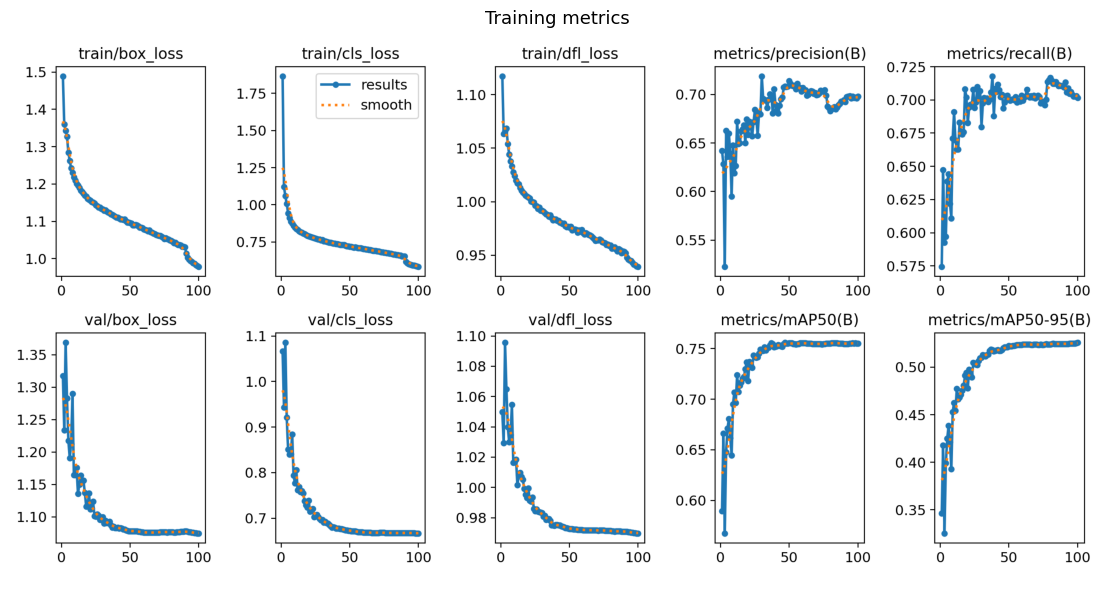

In [12]:
results_img = Path(results.save_dir) / "results.png"

if results_img.exists():
    img = plt.imread(str(results_img))
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Training metrics", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("results.png not found — training may still be running.")


## 🔲 Step 10 — Confusion Matrix

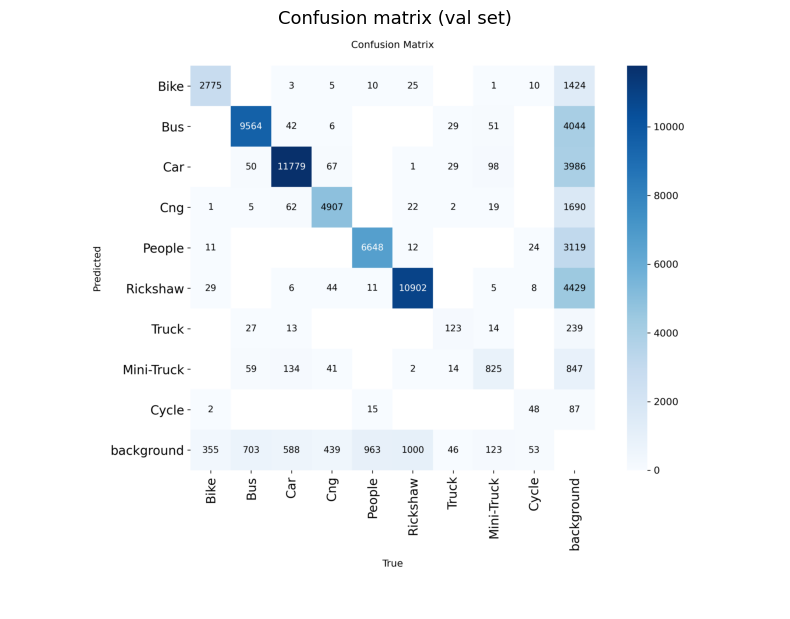

In [13]:
conf_matrix = Path(results.save_dir) / "confusion_matrix.png"

if conf_matrix.exists():
    img = plt.imread(str(conf_matrix))
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Confusion matrix (val set)", fontsize=13)
    plt.tight_layout()
    plt.show()


## 🎯 Step 11 — Inference & Object Counting


image 1/1 /media/softograph/sg-ai/Untitled Folder/raw/images/frame113_jpg.rf.87d1f645f9a5120e4ea7f123032f9ddc.jpg: 480x640 5 Buss, 1 Car, 4 Cngs, 1 People, 4 Rickshaws, 36.2ms
Speed: 0.8ms preprocess, 36.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

Detection results  →  frame113_jpg.rf.87d1f645f9a5120e4ea7f123032f9ddc.jpg
  Class         Count
  --------------------
  Bike              0
  Bus               5
  Car               1
  Cng               4
  People            1
  Rickshaw          4
  Truck             0
  Mini-Truck        0
  Cycle             0
  --------------------
  TOTAL            15


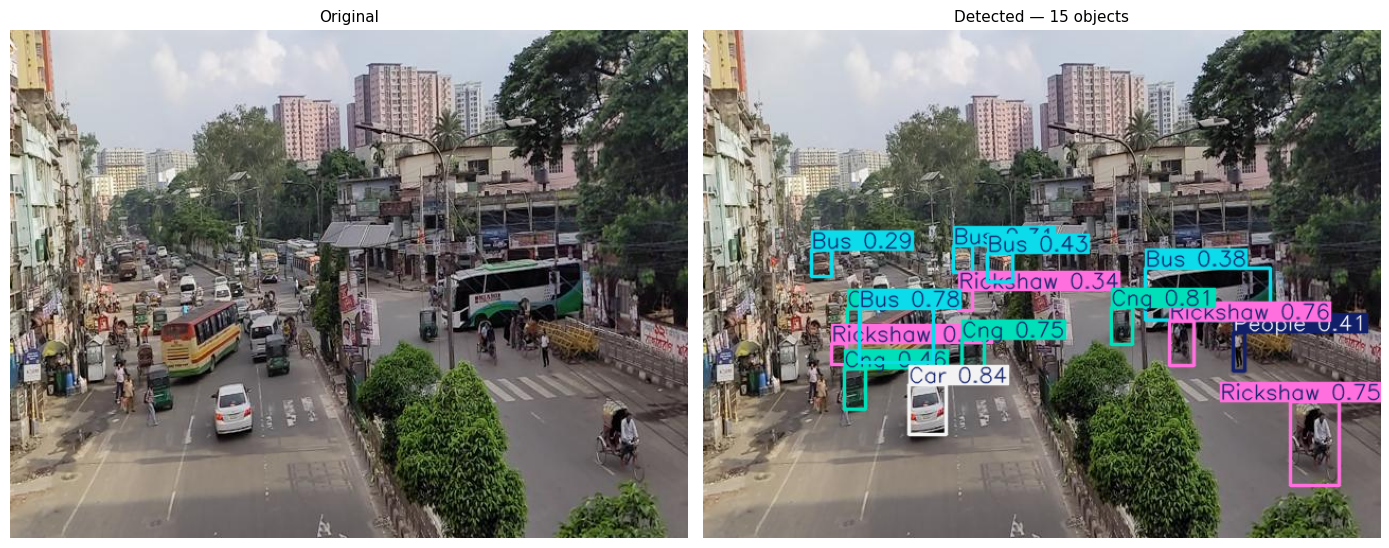

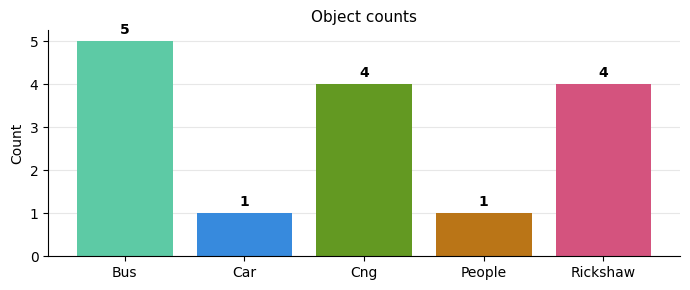

In [14]:
def detect_and_count(image_path, weights, classes, conf=0.25):
    """Run inference on one image, print per-class counts, show result."""
    model   = YOLO(str(weights))
    results = model(str(image_path), conf=conf)[0]

    cls_ids = results.boxes.cls.cpu().numpy().astype(int).tolist()
    counts  = Counter(classes[i] for i in cls_ids)

    # ── Print table ──────────────────────────────────────────────────────
    print(f"\nDetection results  →  {Path(image_path).name}")
    print(f"  {'Class':<12} {'Count':>6}")
    print("  " + "-"*20)
    total = 0
    for cls in classes:
        n = counts.get(cls, 0)
        print(f"  {cls:<12} {n:>6}")
        total += n
    print("  " + "-"*20)
    print(f"  {'TOTAL':<12} {total:>6}")

    # ── Visualize ────────────────────────────────────────────────────────
    annotated = results.plot()          # BGR numpy array
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(plt.imread(str(image_path)))
    axes[0].set_title("Original", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(annotated_rgb)
    axes[1].set_title(f"Detected — {total} objects", fontsize=11)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    # ── Count bar chart ──────────────────────────────────────────────────
    labels = [c for c in classes if counts.get(c, 0) > 0]
    vals   = [counts[c] for c in labels]
    colors = ["#5DCAA5","#378ADD","#639922","#BA7517","#D4537E","#D85A30"][:len(labels)]

    if labels:
        fig2, ax2 = plt.subplots(figsize=(7, 3))
        bars = ax2.bar(labels, vals, color=colors, edgecolor="none", zorder=2)
        ax2.bar_label(bars, padding=3, fontsize=10, fontweight="bold")
        ax2.set_title("Object counts", fontsize=11)
        ax2.set_ylabel("Count")
        ax2.grid(axis="y", alpha=0.3, zorder=1)
        ax2.spines[["top","right"]].set_visible(False)
        plt.tight_layout()
        plt.show()

    return counts


# ── Run on a test image ───────────────────────────────────────────────────────
TEST_IMAGE = "raw/images/frame113_jpg.rf.87d1f645f9a5120e4ea7f123032f9ddc.jpg"   # ← change this

if Path(TEST_IMAGE).exists() and BEST_WEIGHTS.exists():
    counts = detect_and_count(TEST_IMAGE, BEST_WEIGHTS, CLASSES)
else:
    print("⚠️  Set TEST_IMAGE to a valid path and make sure training is complete.")


## 📊 Step 12 — Batch Inference on Val Set

In [ ]:
def batch_count(image_dir, weights, classes, conf=0.25, max_images=20):
    """Run inference on a folder, aggregate counts across all images."""
    model  = YOLO(str(weights))
    imgs   = list(Path(image_dir).glob("*.jpg")) + list(Path(image_dir).glob("*.png"))
    imgs   = imgs[:max_images]

    total  = Counter()
    per_image = {}

    for img_path in imgs:
        res     = model(str(img_path), conf=conf, verbose=False)[0]
        ids     = res.boxes.cls.cpu().numpy().astype(int).tolist()
        counts  = Counter(classes[i] for i in ids)
        per_image[img_path.name] = dict(counts)
        total  += counts

    print(f"\nAggregated counts over {len(imgs)} images:")
    print(f"  {'Class':<12} {'Total':>6}  {'Avg/img':>8}")
    print("  " + "-"*30)
    for cls in classes:
        n   = total.get(cls, 0)
        avg = n / len(imgs) if imgs else 0
        print(f"  {cls:<12} {n:>6}  {avg:>8.2f}")

    return per_image, total


if BEST_WEIGHTS.exists():
    val_img_dir = DATASET_ROOT / "images" / "val"
    per_image, grand_total = batch_count(val_img_dir, BEST_WEIGHTS, CLASSES)
else:
    print("⚠️  Train the model first (Step 8).")


## 💾 Step 13 — Export Model (ONNX / TFLite)

In [ ]:
# Uncomment the format you need:

if BEST_WEIGHTS.exists():
    export_model = YOLO(str(BEST_WEIGHTS))
    
    # export_model.export(format="onnx")      # ONNX  (cross-platform)
    # export_model.export(format="tflite")    # TFLite (mobile/edge)
    # export_model.export(format="torchscript")
    
    print("Uncomment a line above to export.")
else:
    print("⚠️  Train first.")
